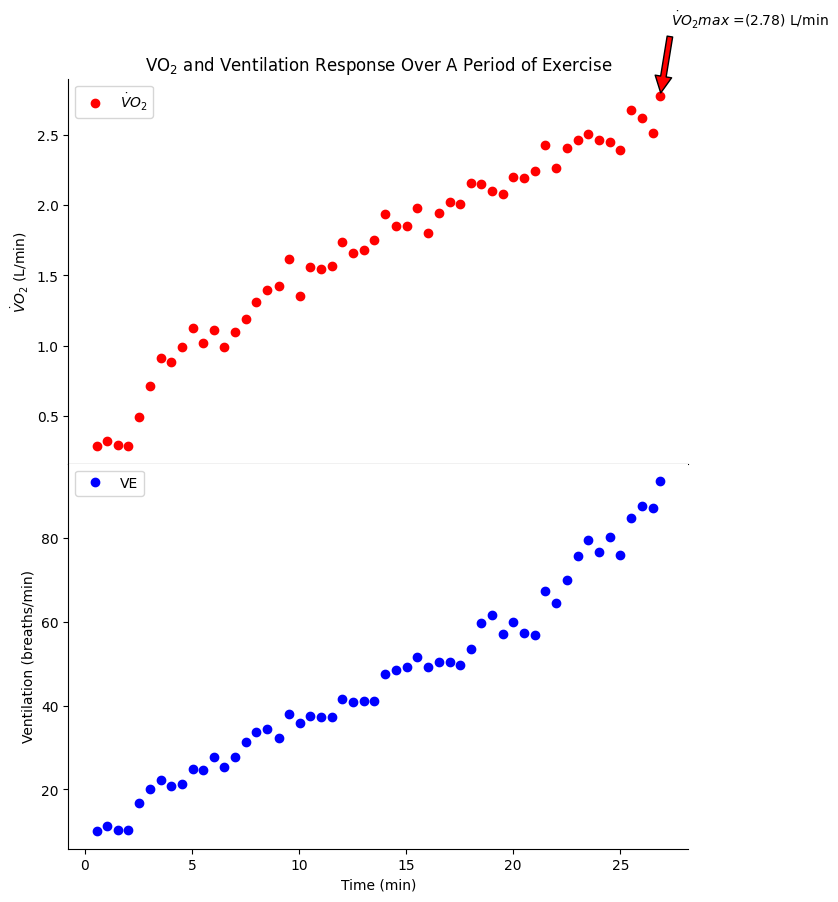

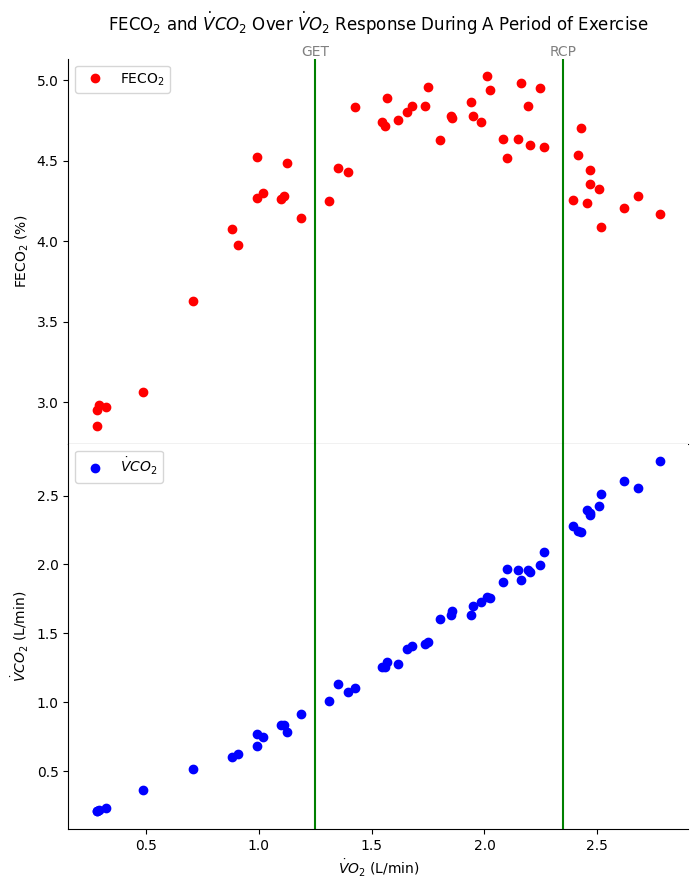

In [19]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

df = pd.read_csv('/kaggle/input/datasets/avanewman8/subject-1321-xlsx/subject_1321(Sheet1).csv', header=[0], skiprows=[1,2,3])

df = df.rename(columns={'VE/': 'VE/VO2','VE/.1': 'VE/VCO2'})

x = df['TIME']
y = df['VO2']
y1 = df['VE']
y2 = df['FECO2']
y3 = df['VCO2']
GET = 1.25
RCP = 2.35

ymax = max(y)

xmax = x[y.argmax()]

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(8, 10)) 

fig.subplots_adjust(hspace=0)

ax[0].annotate(r'$\dot VO_2max$ =({}) L/min'.format(round(ymax, 2)), 
               xy=(xmax, ymax), xytext=(xmax+.5, ymax+ .5),
               arrowprops=dict(facecolor='red', shrink= 0.05),
                )

ax[0].set_title(r'VO$_2$ and Ventilation Response Over A Period of Exercise')
ax[0].plot(x, y, 'o', label=(r'$\dot VO_2$'), c='r' )
ax[0].spines[['right', 'top']].set_visible(False)
ax[0].set(ylabel=(r'$\dot VO_2$ (L/min)'))
ax[0].legend()

ax[1].plot(x, y1, 'o', label=('VE'), c='b')
ax[1].spines[['top', 'right']].set_visible(False)
ax[1].set(ylabel=('Ventilation (breaths/min)'))
ax[1].set(xlabel=('Time (min)'))
ax[1].legend()

fig.savefig("VO2-VE-4.png", dpi=300, bbox_inches = "tight")
fig.show()

fig, bx = plt.subplots(2, 1, sharex=True, figsize=(8, 10))
fig.subplots_adjust(hspace=0)

bx[0].set_title(r'FECO$_2$ and $\dot VCO_2$ Over $\dot VO_2$ Response During A Period of Exercise', pad=20)
bx[0].plot(y, y2, 'o', label=(r'FECO$_2$'), c='r' )
bx[0].spines['right'].set_visible(False)
bx[0].spines['top'].set_visible(False)
bx[0].set(ylabel=(r'FECO$_2$ (%)'))
bx[0].legend()
bx[0].legend(loc='upper left')
bx[0].axvline(GET, color='green', linewidth=1.5, label='GET')
bx[0].axvline(RCP, color='green', linewidth=1.5, label='RCP')
bx[0].text(GET, bx[0].get_ylim()[1], 'GET',
          color='gray', ha='center', va='bottom')
bx[0].text(RCP, bx[0].get_ylim()[1], 'RCP', 
          color='gray', ha='center', va='bottom')

bx[1].plot(y, y3, 'o', label=(r'$\dot VCO_2$'), c='b')
bx[1].spines['top'].set_visible(False)
bx[1].spines['right'].set_visible(False)
bx[1].set(ylabel=(r'$\dot VCO_2$ (L/min)'))
bx[1].set(xlabel=(r'$\dot VO_2$ (L/min)'))
bx[1].legend()

y_top = bx[1].get_ylim()[1]

bx[1].axvline(GET, color='green', linewidth=1.5, label='GET')
bx[1].axvline(RCP, color='green', linewidth=1.5, label='RCP')

fig.show()